A few goals:
- validate that the closed form variance calculations match the variance in the forcing
- compare the variance of the forcing at short timescales to the white noise intensity limit
- show how the forcing intensity could help constrain the continuous timescale and variance of the forcing

In [1]:
import numpy as np
import xarray as xr
from methane_noise_forcing import psd_one_sided_cyclic, closed_form, calculate_mean_and_ci
from methane_noise_forcing.noise import solve_ch4_anomaly_lifetime, simulate_two_timescale_ar1
from methane_noise_forcing.plotting.constants import matplotlib_rcparams, colors_vibrant
import matplotlib.pyplot as plt
plt.rcParams.update(matplotlib_rcparams)

# 1. Does closed form variance calculation match the variance in the forcing?
We're going to target a variance ($\sigma_C^2$) of 100 ppb<sup>2</sup> for the methane anomaly. Using a small time step of 0.1, we'll simulate 10 ensemble members of 1,000 years for timescales of 0.1, 1, and 10 years. We'll then calculate the variance of the methane anomaly from the simulations and compare it to the closed form calculation.

From prior work, we know that the closed form forcing variance ($\sigma_\varepsilon^2$) for a two-timescale AR(1) process is given by:
$$
\sigma_\varepsilon^2 = \sigma_C^2 \left( \frac{\tau_C + \tau_\varepsilon}{\tau_C^2 \, \tau_\varepsilon} \right)
$$

Where $\tau_C$ is the methane lifetime and $\tau_\varepsilon$ is the forcing timescale. We'll use this formula to calculate the expected variance of the forcing for each timescale and compare it to the variance calculated from the simulated methane anomaly.

In [2]:
timescales = [0.01, 0.1, 1.0, 10.0, 100]
var_C_target = 100.0  # Target variance for methane anomaly in ppb^2
n_ensemble = 100
tau_C = 10 # years
dt = 0.01 # Time step in years, works even at 1 year for short timescales due to instantaneous sampling
n_years = 1000 # years

# perform simulation
two_timescale_noise = []
for tau_eta in timescales:
    x_ens, eta_ens = simulate_two_timescale_ar1(
        tau_x=tau_C,
        tau_eta=tau_eta,
        variance_x=var_C_target,
        n_steps=int(n_years / dt),
        dt=dt,
        n_ens=n_ensemble,
    )

    # put into dataset for easier handling
    ds = xr.Dataset(
        {
            "ch4": (("ensemble", "time"), x_ens),
            "forcing": (("ensemble", "time"), eta_ens),
        },
        coords={
            "time": (("time"), np.arange(0, n_years, dt)),
            "ensemble": (("ensemble"), np.arange(n_ensemble)),
        },
    )
    # add dim for timescale to dataset
    ds = ds.expand_dims({"forcing_timescale": [tau_eta]})
    ds = ds.assign_coords({"forcing_timescale": ("forcing_timescale", [tau_eta])})

    two_timescale_noise.append(ds)

# combine all datasets into one
two_timescale_noise = xr.concat(two_timescale_noise, dim="forcing_timescale")

In [3]:
## OPTIONAL
# ensure that the variance is close to the target variance for methane anomaly,
# then scale so that ensemble mean variance matches target variance exactly
for timescale in timescales:
    var_ch4_ens = two_timescale_noise.sel(forcing_timescale=timescale).ch4.var(dim="time")
    print(f"Variance of methane anomaly for forcing timescale {timescale} years: {var_ch4_ens.values.mean()} ± {var_ch4_ens.values.std()} ppb^2")
    scaling_factor = np.sqrt(var_C_target / var_ch4_ens.values.mean())
    two_timescale_noise.loc[dict(forcing_timescale=timescale)] *= scaling_factor

Variance of methane anomaly for forcing timescale 0.01 years: 98.30824315028464 ± 13.705607236869932 ppb^2
Variance of methane anomaly for forcing timescale 0.1 years: 98.37960685050128 ± 15.102994459369775 ppb^2
Variance of methane anomaly for forcing timescale 1.0 years: 96.19034425737283 ± 15.686615704436717 ppb^2
Variance of methane anomaly for forcing timescale 10.0 years: 94.26822894910252 ± 20.99199193420559 ppb^2
Variance of methane anomaly for forcing timescale 100 years: 77.76627600940094 ± 38.004488049443204 ppb^2


In [4]:
# calculate curve for closed form variance calculation
timescales_closed_form = np.logspace(-2, 2, 100)
methane_to_forcing_var_ratio = closed_form.calculate_two_timescale_variance_ratio_methane_to_ar1_forcing(
    tau_methane=tau_C,
    tau_forcing=timescales_closed_form,
)
var_forcing_closed_form = var_C_target / methane_to_forcing_var_ratio

Text(0, 0.5, 'Variance of forcing (ppb$^2$ / year$^2$)')

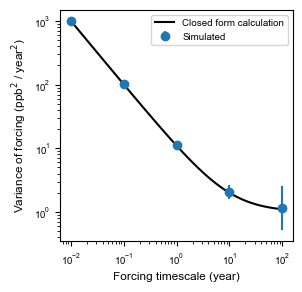

In [5]:
# plot closed form variance vs. variance from simulation for each timescale

fig, ax = plt.subplots(figsize=(3, 3))

# plot closed form variance calculation
ax.plot(
    timescales_closed_form,
    var_forcing_closed_form,
    label="Closed form calculation",
    color="black",
)

# plot variance from simulation for each timescale
for i, timescale in enumerate(timescales):
    mean, ci_low, ci_high = calculate_mean_and_ci(two_timescale_noise.sel(forcing_timescale=timescale).forcing.var(dim="time", ddof=1))
    ax.errorbar(
        timescale,
        mean,
        yerr=[[mean - ci_low], [ci_high - mean]],
        fmt="o",
        label="Simulated" if i == 0 else None,
        color='tab:blue'
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.set_xlabel("Forcing timescale (year)")
ax.set_ylabel("Variance of forcing (ppb$^2$ / year$^2$)")

The closed-form solution matches the empirical rather well regardless of if the simulations are scaled to the target variance or not, which is reassuring. 

Additionally, this confirms that the method I use can use 1-year time steps to resolve the variability of short-timescale forcings down to even 0.01 years without any issues. I presume this occurs because my method is an instantaneous sample of the underlying continuous-time process, which is not the same as sampling the continuous-time process with time averages, though I need to explore this further below.

# 2. Check for convergence of variance to white noise at short timescales
Next, we want to check if the variance of the forcing converges to the white noise limit. This is non-trivial because the units don't match. If the forcing was white instead of red, the variance of the forcing would be typical of the innovation variance of the AR(1) process, which is given by:
$$
\sigma_\varepsilon^2 = \sigma_C^2 \left( \frac{2}{\tau_C} \right)
$$
Note how the units of the variance are ppb<sup>2</sup>/year, which is different from the units of the variance of the forcing for a two-timescale process, which is ppb<sup>2</sup>/year<sup>2</sup>.

Because the methane lifetime is in essence a low-pass filter, we expect that any forcing of a short-enough timescale will be essentially "white" to methane oxidation, and thus the forcing "intensity" should converge to the white noise limit as the forcing timescale approaches zero. The Fourier transform for the red-noise forcing is calculated as follows (in angular frequency space):
$$
S_\varepsilon(\omega) = \int_{-\infty}^{\infty} R_\varepsilon(\tau) e^{-i \omega \tau} d\tau = \frac{2 \, \sigma_\varepsilon^2 \, \tau_\varepsilon}{1 + \omega^2 \, \tau_\varepsilon^2}
$$
Where $R_\varepsilon(\tau)$ is the autocovariance of the forcing $\sigma_\varepsilon^2 \exp(-|\tau|/\tau_\varepsilon)$, and $\omega$ is the angular frequency.

At short enough timescales (essentially white noise), the Fourier transform of the forcing should converge to the white noise limit, which is given by:
$$
S_\varepsilon(0) = 2 \, \sigma_\varepsilon^2 \, \tau_\varepsilon
$$
Substituting the closed-form solution for the variance of the forcing and taking the limit as $\tau_\varepsilon \to 0$, we find that the forcing intensity converges to the white noise limit.

Since I'm using the one-sided PSD to calculate the forcing intensity, double the white noise limit to account for the fact that the one-sided PSD only includes positive frequencies.

In [6]:
## calculate fourier transform of the forcing for each timescale
psd_results = {}
for timescale in timescales:
    psd = []
    for ens in two_timescale_noise.ensemble.values:
        forcing = two_timescale_noise.sel(ensemble=ens, forcing_timescale=timescale).forcing.values
        # freqs, power_spectrum = calculate_fourier_transform_fft(forcing, dt=dt)
        freqs, power_spectrum = psd_one_sided_cyclic(forcing, dt=dt)
        psd.append(np.abs(power_spectrum))
    psd_results[timescale] = xr.DataArray(
        data=np.array(psd),
        dims=["ensemble", "frequency"],
        coords={
            "ensemble": two_timescale_noise.ensemble.values,
            "frequency": freqs,
        },
    )
psds_empirical = xr.concat([psd_results[timescale] for timescale in timescales], dim="forcing_timescale")
psds_empirical = psds_empirical.assign_coords({"forcing_timescale": ("forcing_timescale", timescales)})

In [7]:
## colors of the lines for each timescale in the PSD plot
colors = {
    0.01: colors_vibrant["blue"],
    0.1: colors_vibrant["orange"],
    1.0: colors_vibrant["grey"],
    10.0: colors_vibrant["red"],
    100.0: colors_vibrant["cyan"],
}

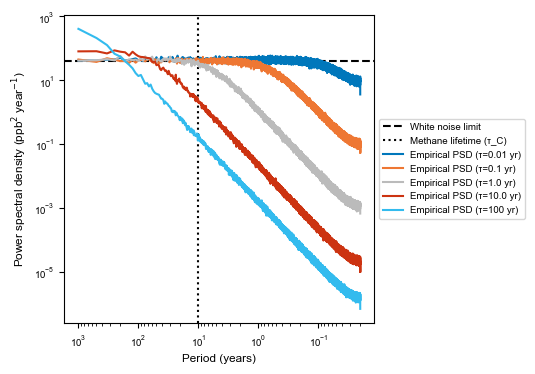

In [8]:
## plot empirical PSD against white noise limit
fig, ax = plt.subplots(figsize=(4, 4))
# white noise
var_innovation = var_C_target * 2 / tau_C * 2 # factor of 2 for one-sided PSD
ax.axhline(var_innovation, color='k', linestyle='--', label='White noise limit')
ax.axvline(tau_C, color='k', linestyle=':', label='Methane lifetime (τ_C)')

for timescale in timescales:
    psd = psds_empirical.sel(forcing_timescale=timescale)
    # plot every 10 points to avoid cluttering the plot too much
    ax.plot(
        1 / psd.frequency,
        psd.mean(dim="ensemble"),
        label=f"Empirical PSD (τ={timescale} yr)",
        color=colors[timescale],
    )
ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()

ax.set_xlabel("Period (years)")
ax.set_ylabel("Power spectral density (ppb$^2$ year$^{-1}$)")
# legend on outside right side of the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

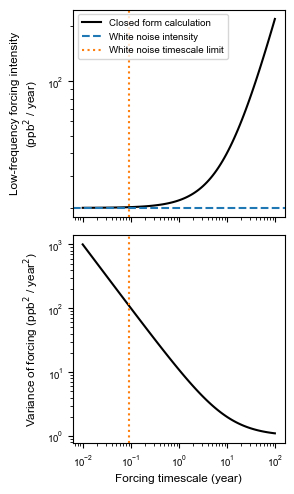

In [9]:
## plot forcing intensity vs. timescale for closed-form calculations
intensity_closed_form = var_forcing_closed_form * 2 * timescales_closed_form
white_noise_intensity = var_C_target * 2 / tau_C

# calculate when white noise intensity is less than 1% different from closed form intensity calculation
tolerance = 0.01 * intensity_closed_form
mask = np.abs(intensity_closed_form - white_noise_intensity) < tolerance
timescale_limit = timescales_closed_form[mask][-1]

fig, axs = plt.subplots(2, 1, figsize=(3, 5), sharex=True)

# plot closed form intensity calculation
axs[0].plot(
    timescales_closed_form,
    intensity_closed_form,
    label="Closed form calculation",
    color="black",
)
axs[0].axhline(white_noise_intensity, color='tab:blue', linestyle='--', label='White noise intensity')
axs[0].axvline(timescale_limit, color='tab:orange', linestyle=':', label='White noise timescale limit')
axs[0].legend()

axs[0].set_yscale('log')
axs[0].set_ylabel("Low-frequency forcing intensity\n(ppb$^2$ / year)")

# plot closed form variance calculation
axs[1].plot(
    timescales_closed_form,
    var_forcing_closed_form,
    label="Closed form calculation",
    color="black",
)
axs[1].axvline(timescale_limit, color='tab:orange', linestyle=':', label='White noise timescale limit')

axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel("Forcing timescale (year)")
axs[1].set_ylabel("Variance of forcing (ppb$^2$ / year$^2$)")

plt.tight_layout()